<a href="https://colab.research.google.com/github/adrianmrizo/Client-Segmentation-Analysis/blob/main/Adrian_Travel_Tide_Mastery_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travel Tide - Client Segmentation**

## 1. EDA before cohort cut-off

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


#import "sessions vs users" dataset
data_spu = '/content/sessions_per_user.csv'
data_cumulative = '/content/cumulative_revenue_per_sessions.csv'
data_bucket = '/content/summary_cut_off_criteria.csv'
data_convers = '/content/booking_rate.csv'


#Create DataFrame
df_spu = pd.read_csv(data_spu)
df_spu.head()

,user_id,total_sessions
0,507513,12
1,522086,11
2,512706,11
3,566059,11
4,520063,11


I've modified the query to include the `booking_rate` column:

1.  **`sessions_per_user` CTE**: A new column `total_booked_sessions` is added, counting sessions where `trip_id` is not NULL.
2.  **`user_features_base` CTE**: The `booking_rate` is calculated by dividing `total_booked_sessions` by `total_sessions`.

This `booking_rate` will now be part of the `user_features` CTE and consequently included in your final `SELECT` statement.

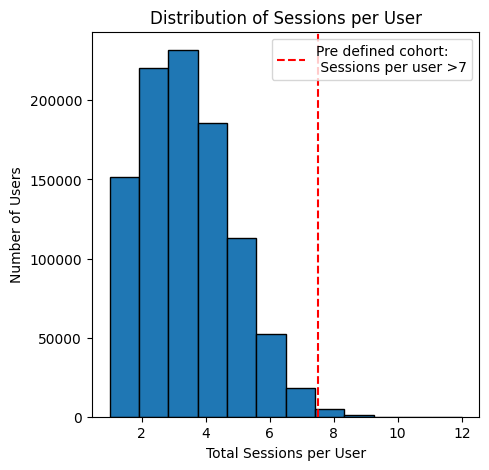

In [ ]:
plt.figure(figsize=(5,5))
plt.hist(df_spu['total_sessions'], bins=12, edgecolor='black',)
plt.xlabel("Total Sessions per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Sessions per User")
plt.axvline(7.5, color='red', linestyle='--', label='Pre defined cohort: \n Sessions per user >7') # Add reference line at x=7
plt.legend()
plt.show()

After running the following query I found out that with our cohort definition we ar excluding more than the 99% of the users. The query result said that we are working with only 0,59% of the users, less than 1%. I'll conduct further analysis two verify if the pre defined cohort has a meaninful definiton.

In [ ]:
df_cumulative = pd.read_csv(data_cumulative)
df_bucket = pd.read_csv(data_bucket)
df_convers = pd.read_csv(data_convers)

df_cumulative.head()

,total_sessions,bucket_revenue,cumulative_revenue,cumulative_revenue_pct
0,12,0,0,0.0000
1,11,31603,31603,0.0014
2,10,468317,499920,0.0216
3,9,3475773,3975693,0.1718
4,8,16924742,20900435,0.9031


In [ ]:
df_bucket.head()


,total_sessions,users,total_trips,total_completed_trips,avg_trips_per_user,avg_complete_trips,avg_cancelled_trips,cancel_rate,avg_revenue_per_user
0,1,151419,88450,83831,0.5841,0.5536,0.0305,5.2222,1571.26
1,2,220315,205307,191043,0.9319,0.8671,0.0647,6.9476,2120.18
2,3,231808,296633,282766,1.2796,1.2198,0.0598,4.6748,2353.14
3,4,185735,301292,291156,1.6222,1.5676,0.0546,3.3642,2628.70
4,5,113045,220609,214324,1.9515,1.8959,0.0556,2.8489,2896.12


In [ ]:
df_convers.head()

,total_sessions,total_sessions_count,total_bookings,booking_rate
0,1,151419,88450,58.41
1,2,440630,217510,49.36
2,3,695424,309028,44.44
3,4,742940,310686,41.82
4,5,565225,226587,40.09


In [ ]:
df_cumulative.info()
df_bucket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   total_sessions          12 non-null     int64  
 1   bucket_revenue          12 non-null     int64  
 2   cumulative_revenue      12 non-null     int64  
 3   cumulative_revenue_pct  12 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 516.0 bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_sessions         12 non-null     int64  
 1   users                  12 non-null     int64  
 2   total_trips            12 non-null     int64  
 3   total_completed_trips  12 non-null     int64  
 4   avg_trips_per_user     12 non-null     float64
 5   avg_complete_trips     12 non-null     float64
 6   av

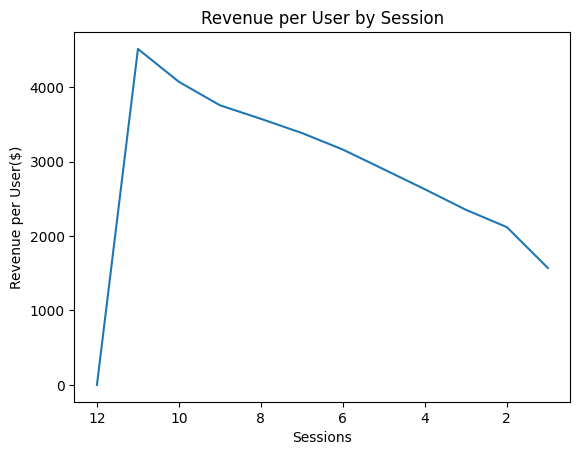

In [ ]:
# Revenue per user per session bucket
plt.figure()

plt.plot(
    df_bucket['total_sessions'],
    df_bucket['avg_revenue_per_user']
)

plt.xlabel("Sessions")
plt.ylabel("Revenue per User($)")
plt.title("Revenue per User by Session")

plt.gca().invert_xaxis()

plt.show()

Users with more sessions have more average revenue per user, esception Sessions = 12 where only one user doesnt have any bookings yet.

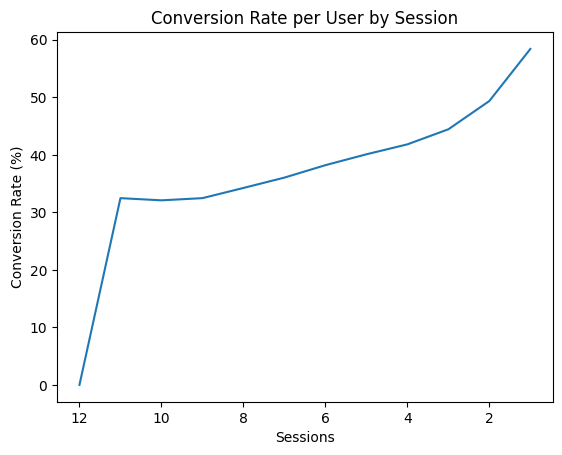

In [ ]:
# Convertion Rate
plt.figure()

plt.plot(
    df_convers['total_sessions'],
    df_convers['booking_rate']
)

plt.xlabel("Sessions")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate per User by Session")

plt.gca().invert_xaxis()

plt.show()

BUt we also see that the convertion rate drops with the number of sessions

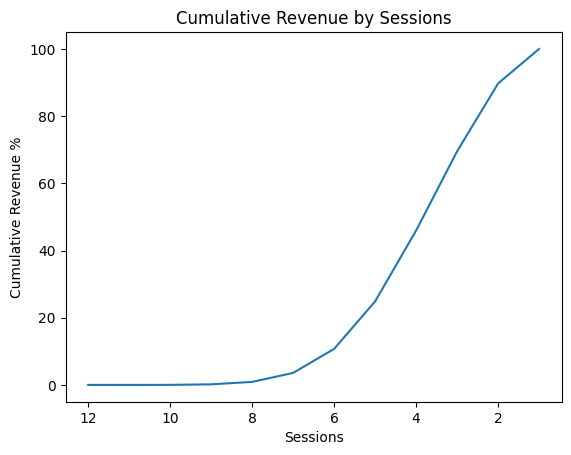

In [ ]:
plt.figure()

plt.plot(
    df_cumulative['total_sessions'],
    df_cumulative['cumulative_revenue_pct']
)

plt.xlabel("Sessions")
plt.ylabel("Cumulative Revenue %")
plt.title("Cumulative Revenue by Sessions")

plt.gca().invert_xaxis()  # clave

plt.show()

The revenue share per session bucket, tell us that our pre defined coohort session > 7 has les than 1% of the total revenue share. Sessions >= 4 has almost the half of the share (46%). That could be a good staritng point.

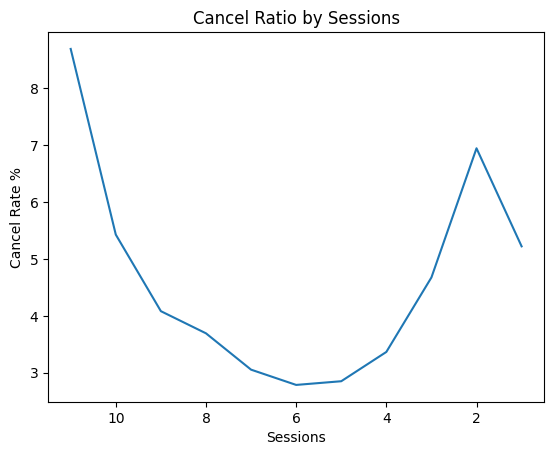

In [ ]:
plt.figure()

plt.plot(
    df_bucket['total_sessions'],
    df_bucket['cancel_rate']
)

plt.xlabel("Sessions")
plt.ylabel("Cancel Rate %")
plt.title("Cancel Ratio by Sessions")

plt.gca().invert_xaxis()

plt.show()

Users with more than 7 sessons tend to cancel more often than users with fewer sessions. Betwee 4 and 7 sessions we have the smaller cancel rate.

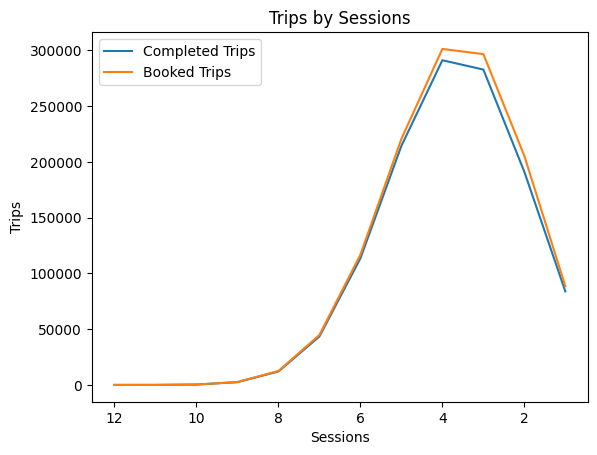

In [ ]:
plt.plot(
    df_bucket['total_sessions'],
    df_bucket['total_completed_trips'],
    label='Completed Trips'
)

plt.plot(
    df_bucket['total_sessions'],
    df_bucket['total_trips'],
    label='Booked Trips'
)

plt.xlabel("Sessions")
plt.ylabel("Trips")
plt.title("Trips by Sessions")

plt.gca().invert_xaxis()

plt.legend()

plt.show()

Bookings that weren't cancelled. From Session > 7 we have less total of trips completed, yes we have less users, but the chart tell us that the bucket sessions 5 has a good chance to land a succesfull booking.

I defined a cutoff at users with ≥5 sessions to identify high-intent and high-value users.

This decision is based on several key observations:

* Revenue Concentration: Users with 5 or more sessions account for approximately 25% of total cumulative revenue, indicating a meaningful contribution despite being a smaller segment.
* User Quality: These users exhibit the lowest cancellation rates, particularly in the 5–6 session range, suggesting more reliable and committed booking behavior.
* Conversion Efficiency: The segment shows a conversion rate of around 40%, significantly higher than higher-session users, indicating stronger purchase intent.
* User Base Size: Importantly, this group still represents ~20% of the total user base, ensuring that the segment is large enough to be actionable for marketing and retention strategies.

Overall, this cutoff effectively balances revenue impact, behavioral quality, and segment size, making it a strong candidate for targeted business actions.

While ≥3 sessions captures a larger share of revenue, ≥5 sessions provides a cleaner segmentation of highly engaged and reliable users, with stronger behavioral signals such as lower cancellations and higher conversion rates.

## 2. EDA and FeaturePrep with "user_features"

We built the `user_features` table through a structured pipeline designed to capture user behavior, engagement, and value at a consistent user level. The process started with the creation of a clean `trips` table, where we consolidated booking information from sessions, flights, and hotels into a single trip-level dataset. During this step, we carefully handled data quality issues by removing inconsistent records, correcting invalid values, and ensuring that revenue and timing variables were logically consistent.

Once the trips table was validated, we aggregated both session-level and trip-level data to the user level. This allowed us to construct features that describe user engagement, such as total sessions and interaction metrics, as well as transactional behavior, including number of trips, revenue, and conversion-related measures. We also derived efficiency metrics like revenue per session to better understand user performance.

Special attention was given to handling missing values in a way that preserves their meaning, distinguishing between users with no activity and users with zero outcomes. Finally, we engineered composite indices to summarize complex behavior, such as activity and value, using log transformations to stabilize distributions.

To focus the analysis on meaningful behavior, we defined a cohort of users with at least five sessions. This threshold isolates users with clear purchase intent, higher conversion rates, lower cancellation behavior, and a significant contribution to overall revenue. The resulting dataset provides a clean and robust foundation for exploratory analysis, segmentation, and machine learning applications.


In [ ]:
df = pd.read_csv('/content/user_features.csv')
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189432 entries, 0 to 189431
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       189432 non-null  int64  
 1   total_sessions                189432 non-null  int64  
 2   conversion_rate               169313 non-null  float64
 3   avg_page_clicks               189432 non-null  float64
 4   total_page_clicks             189432 non-null  int64  
 5   avg_session_duration_minutes  189432 non-null  float64
 6   last_session                  189432 non-null  object 
 7   total_trips                   189432 non-null  int64  
 8   completed_trips               189432 non-null  int64  
 9   trips_per_session             189432 non-null  float64
 10  total_revenue                 189432 non-null  float64
 11  avg_revenue_per_trip          169313 non-null  float64
 12  revenue_per_session           189432 non-nul

,user_id,total_sessions,conversion_rate,avg_page_clicks,total_page_clicks,avg_session_duration_minutes,last_session,total_trips,completed_trips,trips_per_session,...,hotel_ratio,avg_distance_km,account_age_days,age,has_children,married,activity_index,value_index,quality_index,user_segment
0,134,5,40.0,18.4,92,2.28,2023-07-19 17:03:39.000,2,2,0.4,...,1.0,1652.0,877,35,True,False,0.516960,3.060878,3.437390,low_value_low_activity
1,453,5,60.0,15.4,77,1.92,2023-05-17 12:42:14.000,3,3,0.6,...,1.0,1492.0,865,28,False,False,0.439941,5.074680,4.190202,high_value_low_activity
2,519,5,20.0,8.2,41,1.02,2023-06-11 18:13:15.000,1,1,0.2,...,1.0,2166.0,864,45,False,False,0.229005,1.710862,2.836868,low_value_low_activity
3,577,5,NaN,11.4,57,1.41,2023-06-05 17:03:28.000,0,0,0.0,...,NaN,NaN,863,41,False,False,0.325038,0.000000,0.000000,low_value_low_activity
4,638,5,NaN,10.0,50,1.25,2023-03-20 11:30:16.000,0,0,0.0,...,NaN,NaN,858,21,False,False,0.285395,0.000000,0.000000,low_value_low_activity


In [ ]:
df_prep = df.copy()

# create flags two easily identify the users with no activity later
df_prep['has_trips'] = df_prep['total_trips'] > 0
df_prep['has_revenue'] = df_prep['total_revenue'] > 0

print("Descriptive Statistics:")
print(df_prep.info())

print("\nMissing Values:")
print(df_prep.isnull().sum())

Descriptive Statistics:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189432 entries, 0 to 189431
Data columns (total 31 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       189432 non-null  int64  
 1   total_sessions                189432 non-null  int64  
 2   conversion_rate               169313 non-null  float64
 3   avg_page_clicks               189432 non-null  float64
 4   total_page_clicks             189432 non-null  int64  
 5   avg_session_duration_minutes  189432 non-null  float64
 6   last_session                  189432 non-null  object 
 7   total_trips                   189432 non-null  int64  
 8   completed_trips               189432 non-null  int64  
 9   trips_per_session             189432 non-null  float64
 10  total_revenue                 189432 non-null  float64
 11  avg_revenue_per_trip          169313 non-null  float64
 12  revenue_per_session 

In [ ]:
print("Descriptive Statistics:")
print(df_prep.describe().T)

Descriptive Statistics:
                                 count           mean            std  \
user_id                       189432.0  570196.851598  144181.270497   
total_sessions                189432.0       5.567016       0.812725   
conversion_rate               169313.0      40.779616      20.476660   
avg_page_clicks               189432.0      17.841466       9.433302   
total_page_clicks             189432.0      99.209701      54.173250   
avg_session_duration_minutes  189432.0       3.023217       4.472011   
total_trips                   189432.0       2.076666       1.267742   
completed_trips               189432.0       2.016259       1.284126   
trips_per_session             189432.0       0.375460       0.227296   
total_revenue                 189432.0    2707.563189    3999.019563   
avg_revenue_per_trip          169313.0    1343.908861    2161.530552   
revenue_per_session           189432.0     491.164624     739.702614   
avg_trip_duration             165823.0  

In [ ]:
df_prep.head()

,user_id,total_sessions,conversion_rate,avg_page_clicks,total_page_clicks,avg_session_duration_minutes,last_session,total_trips,completed_trips,trips_per_session,...,account_age_days,age,has_children,married,activity_index,value_index,quality_index,user_segment,has_trips,has_revenue
0,134,5,40.0,18.4,92,2.28,2023-07-19 17:03:39.000,2,2,0.4,...,877,35,True,False,0.516960,3.060878,3.437390,low_value_low_activity,True,True
1,453,5,60.0,15.4,77,1.92,2023-05-17 12:42:14.000,3,3,0.6,...,865,28,False,False,0.439941,5.074680,4.190202,high_value_low_activity,True,True
2,519,5,20.0,8.2,41,1.02,2023-06-11 18:13:15.000,1,1,0.2,...,864,45,False,False,0.229005,1.710862,2.836868,low_value_low_activity,True,True
3,577,5,NaN,11.4,57,1.41,2023-06-05 17:03:28.000,0,0,0.0,...,863,41,False,False,0.325038,0.000000,0.000000,low_value_low_activity,False,False
4,638,5,NaN,10.0,50,1.25,2023-03-20 11:30:16.000,0,0,0.0,...,858,21,False,False,0.285395,0.000000,0.000000,low_value_low_activity,False,False


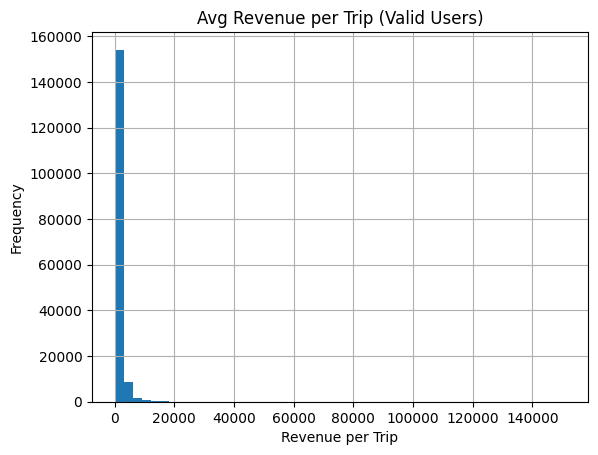

In [ ]:
plt.figure()

df_prep[
    (df_prep['has_trips']) & (df_prep['has_revenue'])
]['avg_revenue_per_trip'].hist(bins=50)

plt.title("Avg Revenue per Trip (Valid Users)")
plt.xlabel("Revenue per Trip")
plt.ylabel("Frequency")

plt.show()

## 3. Segmentation

In [ ]:
# select all the users with no bookings and take a closer look
df_no_purchase = df_prep[(df_prep['total_sessions'] > 0) & (df_prep['has_trips'] == False)]

df_no_purchase.shape[0]

df_no_purchase.info()

df_prep.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 20119 entries, 3 to 189430
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       20119 non-null  int64  
 1   total_sessions                20119 non-null  int64  
 2   conversion_rate               0 non-null      float64
 3   avg_page_clicks               20119 non-null  float64
 4   total_page_clicks             20119 non-null  int64  
 5   avg_session_duration_minutes  20119 non-null  float64
 6   last_session                  20119 non-null  object 
 7   total_trips                   20119 non-null  int64  
 8   completed_trips               20119 non-null  int64  
 9   trips_per_session             20119 non-null  float64
 10  total_revenue                 20119 non-null  float64
 11  avg_revenue_per_trip          0 non-null      float64
 12  revenue_per_session           20119 non-null  float64
 13  avg_t

,0
user_id,0
total_sessions,0
conversion_rate,20119
avg_page_clicks,0
total_page_clicks,0
avg_session_duration_minutes,0
last_session,0
total_trips,0
completed_trips,0
trips_per_session,0


In [ ]:
# which perc represtents the users with no bookings
print(df_no_purchase.shape[0])
print(df_prep.shape[0])
print(df_no_purchase.shape[0] / df_prep.shape[0] * 100)

20119
189432
10.620697664597323


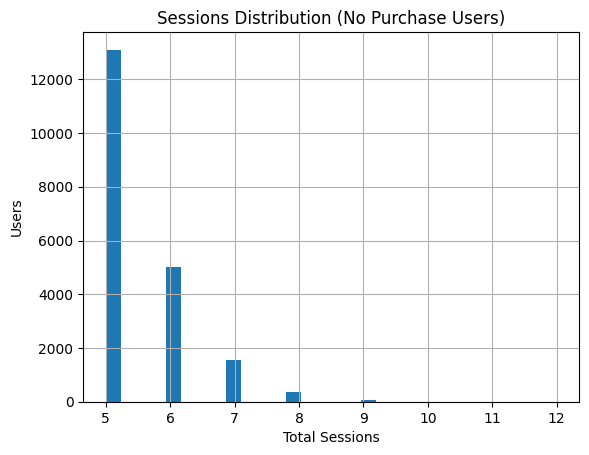

In [ ]:
plt.figure()

df_no_purchase['total_sessions'].hist(bins=30)

plt.title("Sessions Distribution (No Purchase Users)")
plt.xlabel("Total Sessions")
plt.ylabel("Users")

plt.show()

In [ ]:
# quick comparison purchse vs no purchase
df_purchase = df_prep[df_prep['has_trips'] == True]

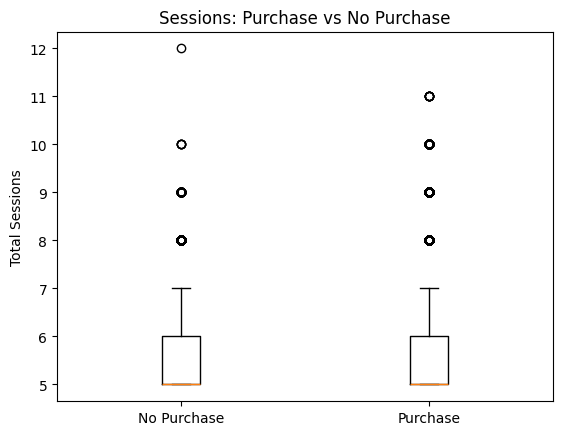

In [ ]:
plt.figure()

plt.boxplot([
    df_no_purchase['total_sessions'],
    df_purchase['total_sessions']
])

plt.xticks([1,2], ['No Purchase', 'Purchase'])
plt.ylabel("Total Sessions")
plt.title("Sessions: Purchase vs No Purchase")

plt.show()

In [ ]:
print(df_no_purchase['total_sessions'].mean())
print(df_purchase['total_sessions'].mean())

5.475023609523336
5.577947351945805


In [ ]:
df_prep['has_trips'].value_counts(normalize=True)

,proportion
has_trips,
True,0.893793
False,0.106207


In [ ]:
print(df_no_purchase['total_sessions'].describe())

count    20119.000000
mean         5.475024
std          0.751219
min          5.000000
25%          5.000000
50%          5.000000
75%          6.000000
max         12.000000
Name: total_sessions, dtype: float64


A significant portion of users (~10%) engage actively with the platform but never convert, despite exhibiting a similar level of activity (avg. ~5.5 sessions) as purchasing users.

User activity alone is not a reliable predictor of conversion. A subset of highly engaged users fails to convert, indicating friction or barriers in the booking process.

I'm going to create my first segment out of it and assign them the "First-Booking Discount" Perk

<Axes: >

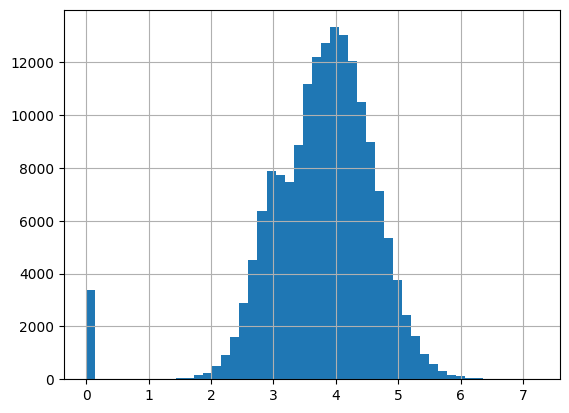

In [ ]:
df_purchase['quality_index'].hist(bins=50)

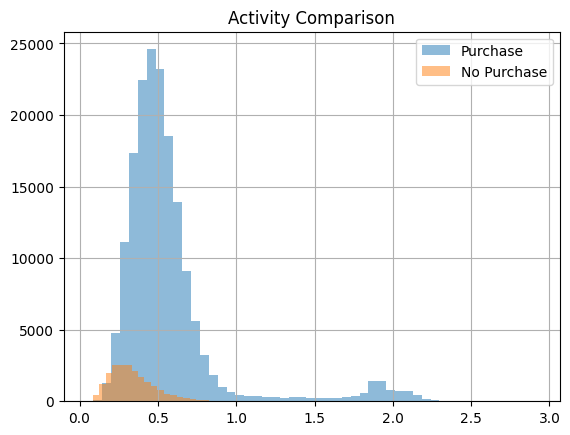

In [ ]:
plt.figure()

df_purchase['activity_index'].hist(bins=50, alpha=0.5)
df_no_purchase['activity_index'].hist(bins=50, alpha=0.5)

plt.legend(['Purchase', 'No Purchase'])
plt.title("Activity Comparison")

plt.show()

In [ ]:
#validating that the segmentation works correctly
print(df_purchase.shape[0] + df_no_purchase.shape[0])
print(len(df_prep))

189432
189432


EDA continues

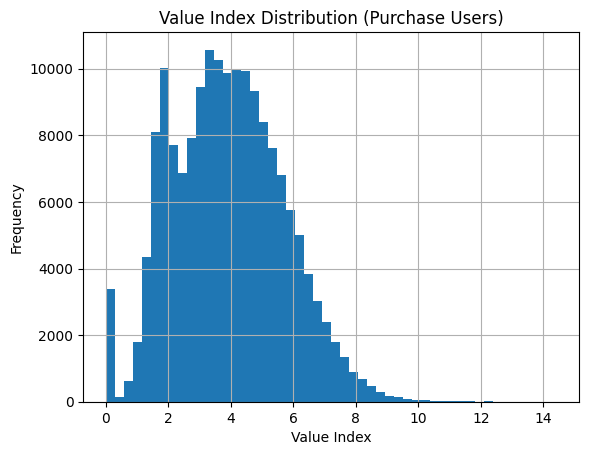

In [ ]:
plt.figure()

df_purchase['value_index'].hist(bins=50)

plt.title("Value Index Distribution (Purchase Users)")
plt.xlabel("Value Index")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df_purchase['value_index'].describe()

,value_index
count,169313.000000
mean,3.912273
std,1.782771
min,0.000000
25%,2.569460
50%,3.849950
75%,5.127790
max,14.420213


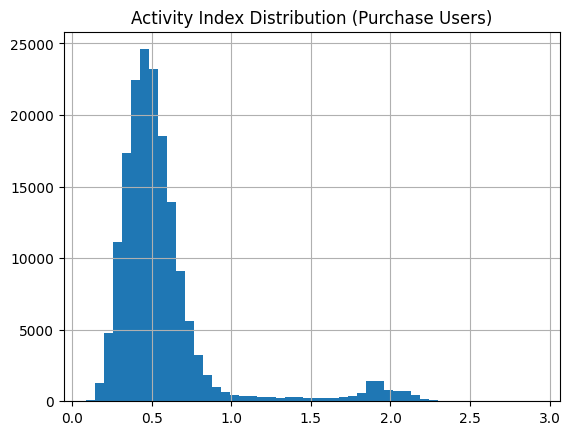

In [ ]:
plt.figure()

df_purchase['activity_index'].hist(bins=50)

plt.title("Activity Index Distribution (Purchase Users)")
plt.show()

In [ ]:
df_purchase['activity_index'].describe()

,activity_index
count,169313.000000
mean,0.569611
std,0.346715
min,0.088696
25%,0.392817
50%,0.491802
75%,0.611058
max,2.920723


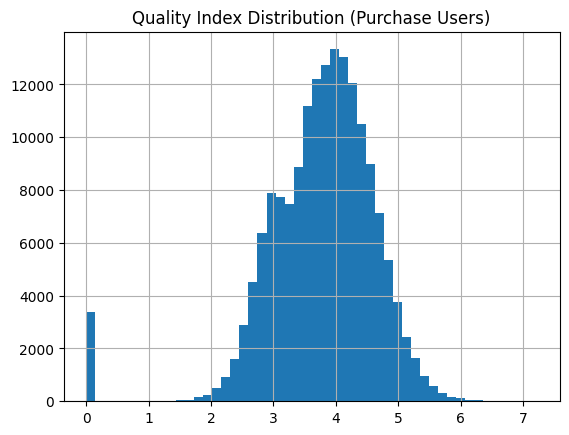

In [ ]:
plt.figure()

df_purchase['quality_index'].hist(bins=50)

plt.title("Quality Index Distribution (Purchase Users)")
plt.show()

In [ ]:
df_purchase['quality_index'].describe()

,quality_index
count,169313.000000
mean,3.766653
std,0.886635
min,0.000000
25%,3.296671
50%,3.855944
75%,4.332087
max,7.226366


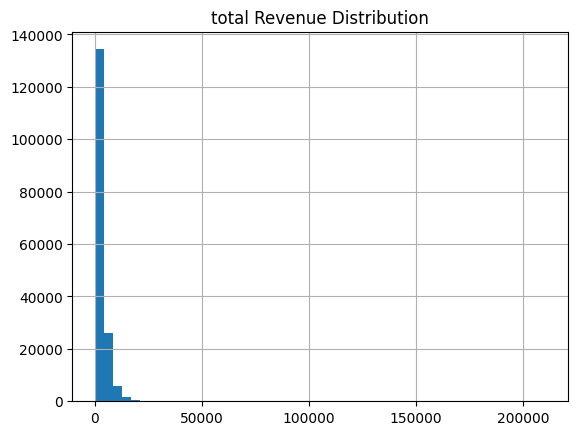

In [ ]:
plt.figure()

df_purchase['total_revenue'].hist(bins=50)

plt.title("total Revenue Distribution")
plt.show()

In [ ]:
df_purchase['total_revenue'].describe()

,total_revenue
count,169313.000000
mean,3029.295506
std,4113.130795
min,0.000000
25%,1059.520000
50%,2071.250000
75%,3734.870000
max,210617.360000


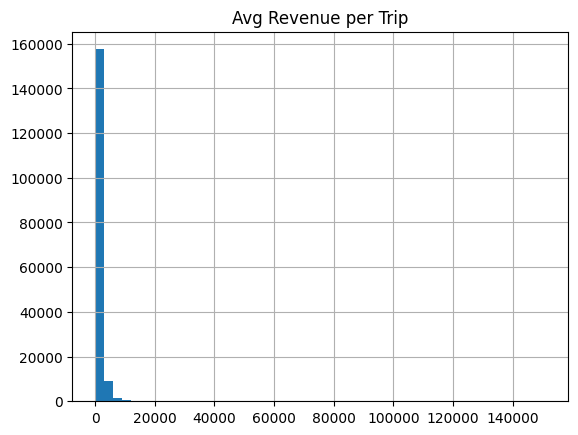

In [ ]:
plt.figure()

df_purchase['avg_revenue_per_trip'].hist(bins=50)

plt.title("Avg Revenue per Trip")
plt.show()

In [ ]:
df_purchase['avg_revenue_per_trip'].describe()

,avg_revenue_per_trip
count,169313.000000
mean,1343.908861
std,2161.530552
min,0.000000
25%,583.130000
50%,893.270000
75%,1473.760000
max,151108.640000


In [ ]:
print(df_purchase['avg_revenue_per_trip'].quantile(0.95))

3578.485999999999


In [ ]:
threshold = df_purchase['total_revenue'].quantile(0.95)
df_high_value = df_purchase[df_purchase['total_revenue'] > threshold]

In [ ]:
df_normal = df_purchase[df_purchase['total_revenue'] <= threshold]

In [ ]:
df_high_value.shape[0] / df_purchase.shape[0] * 100

5.000206717735791

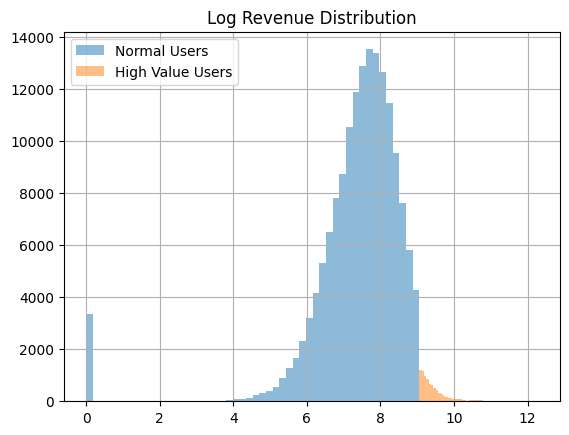

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

np.log1p(df_normal['total_revenue']).hist(bins=50, alpha=0.5)
np.log1p(df_high_value['total_revenue']).hist(bins=50, alpha=0.5)

plt.legend(['Normal Users', 'High Value Users'])
plt.title("Log Revenue Distribution")

plt.show()

In [ ]:
print('high value user')
print(df_high_value['activity_index'].mean())
print(df_high_value['quality_index'].mean())
print(df_high_value['conversion_rate'].mean())
print("standard user")
print(df_normal['activity_index'].mean())
print(df_normal['quality_index'].mean())
print(df_normal['conversion_rate'].mean())

high value user
0.5549088901128973
5.060672252130349
53.80564611386723
standard user
0.570384537219846
3.698544006401277
40.09400523478834


A small subset of users (top 5%) contributes disproportionately to total revenue, indicating a high-value segment with distinct behavioral characteristics. I'll create a anew segment out of this group

We identified a high-value segment representing the top 5% of users by total revenue, who exhibit higher conversion rates, stronger engagement, and superior overall quality scores. This group will be treated as a priority segment due to its disproportionate contribution to business performance.

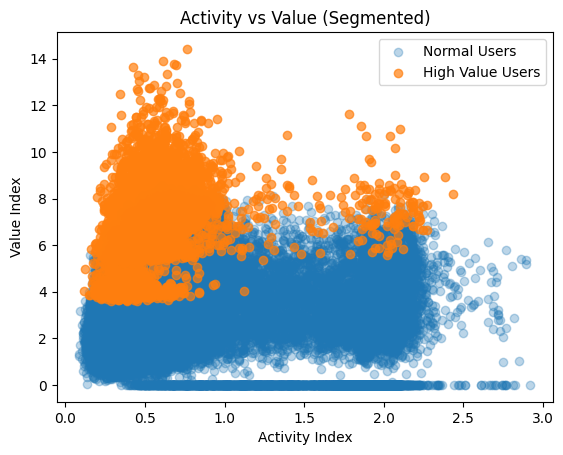

In [ ]:
plt.figure()

plt.scatter(
    df_normal['activity_index'],
    df_normal['value_index'],
    alpha=0.3,
    label='Normal Users'
)

plt.scatter(
    df_high_value['activity_index'],
    df_high_value['value_index'],
    alpha=0.7,
    label='High Value Users'
)

plt.xlabel("Activity Index")
plt.ylabel("Value Index")
plt.title("Activity vs Value (Segmented)")

plt.legend()

Given that this segment is less price-sensitive and demonstrates high purchasing efficiency, the recommended strategy is to focus on experience rather than discounts. Offering priority access, personalized assistance, and a frictionless booking experience is more likely to drive retention and reactivation than traditional monetary incentives.

## 4. ML Clustering

In [ ]:
features = ['activity_index', 'value_index', 'quality_index']

X = df_normal[features]

X = X.fillna(0)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

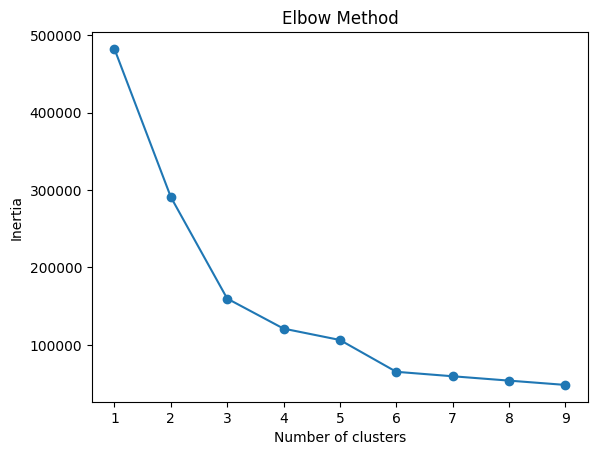

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
df_normal = df_purchase[df_purchase['total_revenue'] <= threshold].copy()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_normal['cluster'] = clusters

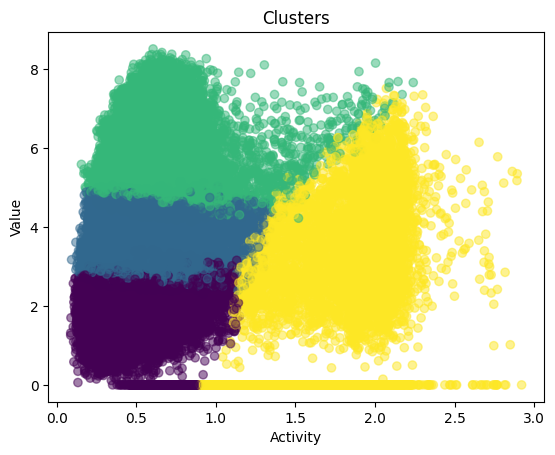

In [ ]:
plt.figure()

plt.scatter(
    df_normal['activity_index'],
    df_normal['value_index'],
    c=df_normal['cluster'],
    alpha=0.5
)

plt.xlabel("Activity")
plt.ylabel("Value")
plt.title("Clusters")

plt.show()

In [ ]:
df_normal.groupby('cluster')[features].mean()

,activity_index,value_index,quality_index
cluster,,,
0,0.414087,1.910895,2.948397
1,0.488127,3.753901,3.826551
2,0.582132,5.704526,4.528381
3,1.818948,2.378634,2.129351


### Clustering using features - no indices

In [ ]:
features = [
    'total_sessions',
    'avg_page_clicks',
    'avg_session_duration_minutes',
    'total_trips',
    'total_revenue',
    'avg_revenue_per_trip',
    'conversion_rate',
    'avg_trip_duration',
    'avg_lead_time'
]

In [ ]:
X = df_normal[features].copy()

In [ ]:
X['avg_lead_time'] = pd.to_numeric(X['avg_lead_time'], errors='coerce')

In [ ]:
X = X.fillna(0)

In [ ]:
import numpy as np

X['total_revenue'] = np.log1p(X['total_revenue'])
X['avg_revenue_per_trip'] = np.log1p(X['avg_revenue_per_trip'])
X['total_sessions'] = np.log1p(X['total_sessions'])
X['avg_page_clicks'] = np.log1p(X['avg_page_clicks'])
X['avg_trip_duration'] = np.log1p(X['avg_trip_duration'])
X['avg_session_duration_minutes'] = np.log1p(X['avg_session_duration_minutes'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

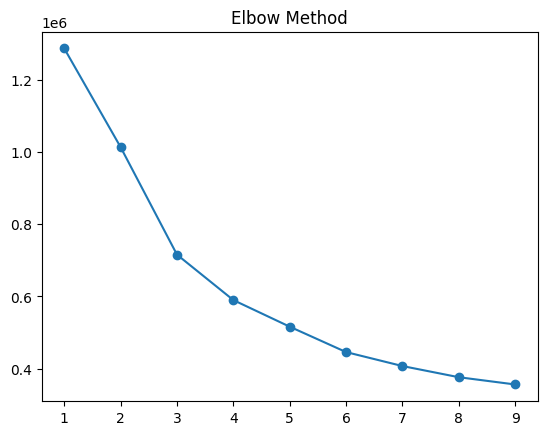

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_normal = df_normal.copy()  # por seguridad
df_normal['avg_lead_time'] = pd.to_numeric(df_normal['avg_lead_time'], errors='coerce')
df_normal['avg_lead_time'].fillna(0)
df_normal['cluster_raw'] = clusters

In [ ]:
df_normal.groupby('cluster_raw')[features].mean()

,total_sessions,avg_page_clicks,avg_session_duration_minutes,total_trips,total_revenue,avg_revenue_per_trip,conversion_rate,avg_trip_duration,avg_lead_time
cluster_raw,,,,,,,,,
0,5.498140,14.847794,1.861355,1.545183,1796.718347,1188.746437,28.407442,5.175576,NaN
1,5.675142,19.550161,2.451392,3.432900,3589.189969,1059.178135,61.248528,4.620110,NaN
2,5.495407,38.502563,18.637265,1.015407,0.077253,0.051947,0.068151,2.666667,NaN
3,5.723301,47.703943,19.889756,2.619556,1828.280232,682.991563,29.364313,4.827037,NaN
